In [33]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pickle

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 5.7 MB/s eta 0:00:18
   - -------------------------------------- 2.6/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.7/101.7 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 4.7/101.7 MB 5.7 MB/s eta 0:00:18
   -- ------------------------------------- 6.0/101.7 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 8.1/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 9.2/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 9.4/101.7 MB 5.2 MB/s eta 0:00:18
   ---- ----------------------------------- 10.7/101.7 MB 5.1 MB/s eta 0:00:18
   ---- ----------------------------------- 12.1/101.7 MB 5.2 MB/s eta 0:00:1


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
df = pd.read_csv("C:\\Users\\Parth\\OneDrive\\Documents\\Desktop\\datasets\\heart_disease_uci.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  

In [40]:
# Safe drop
df = df.drop(["id", "dataset"], axis=1, errors="ignore")

# Convert to binary safely
if "num" in df.columns:
    df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
    df.rename(columns={"num": "target"}, inplace=True)

elif "target" in df.columns:
    df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df.rename(columns={"num": "target"}, inplace=True)

# Fill numeric
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.infer_objects(copy=False)

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [42]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

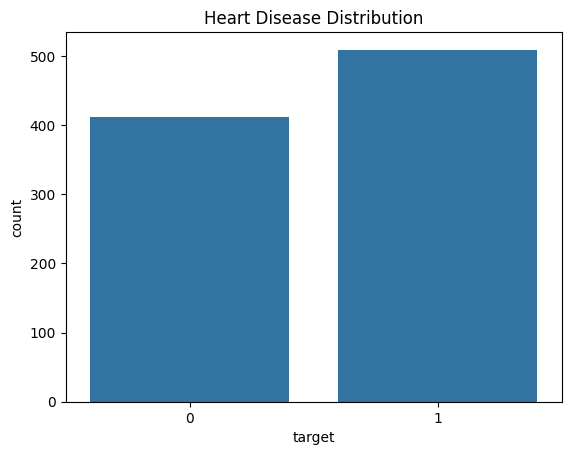

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


In [45]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

print(df["target"].value_counts(normalize=True))

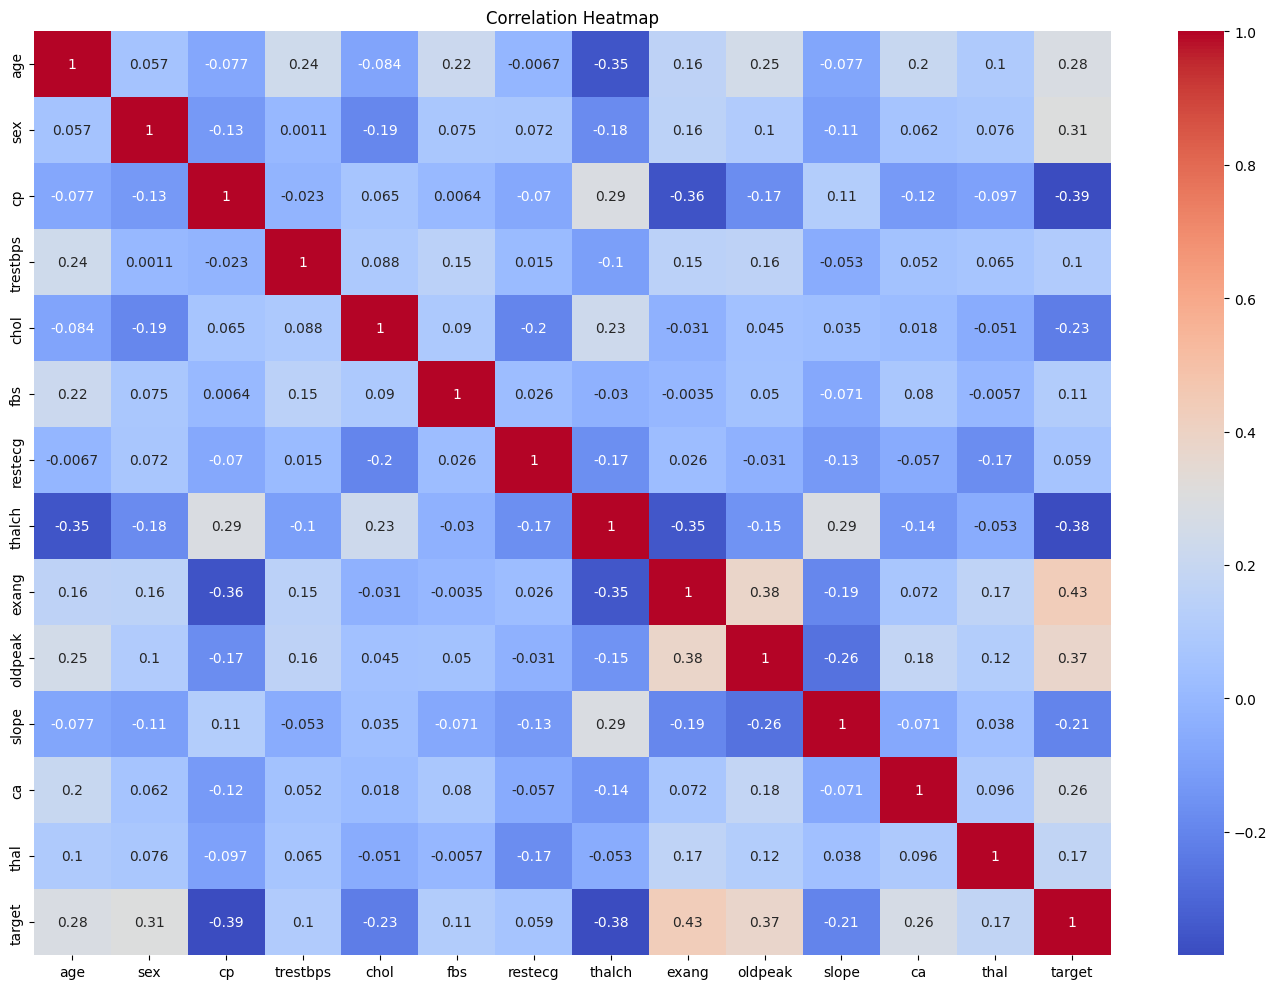

In [47]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

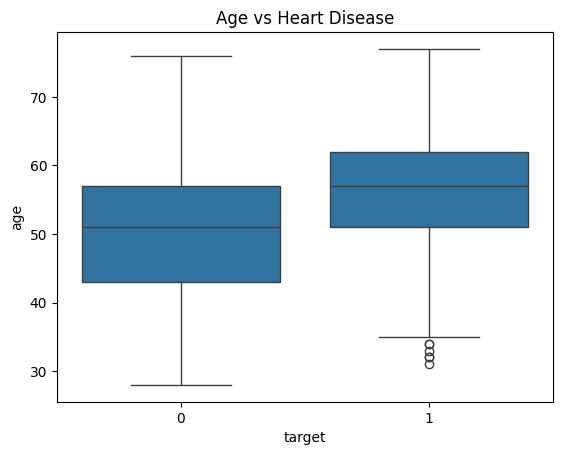

In [48]:
sns.boxplot(x="target", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

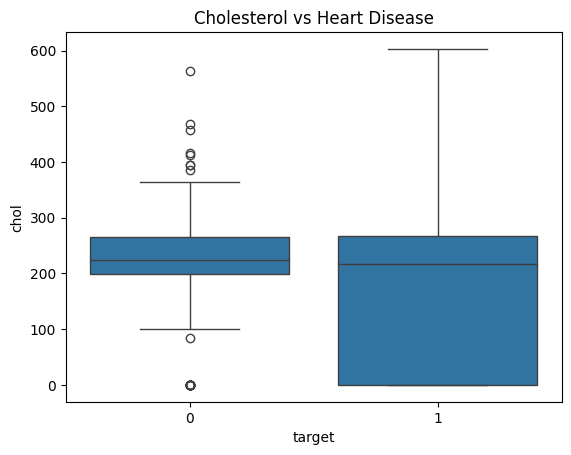

In [49]:
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

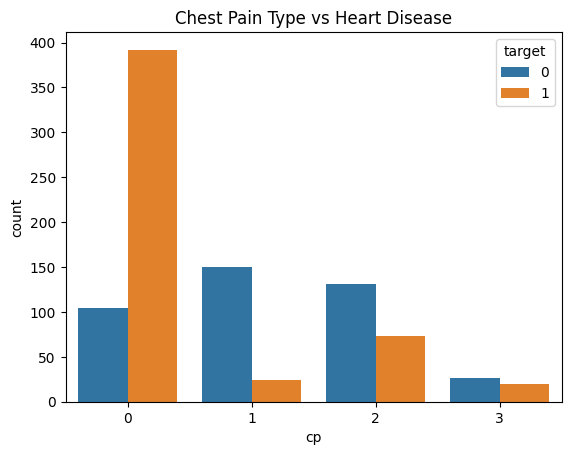

In [50]:
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [51]:
df.groupby("target").mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,50.547445,0.649635,1.192214,130.021042,226.575368,0.107056,0.948905,148.252830,0.133820,0.441739,1.270073,0.516760,1.065693
1,55.903733,0.901768,0.451866,133.837257,176.969418,0.184676,1.023576,128.899997,0.554028,1.231690,1.056974,0.805259,1.233792


In [61]:
X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (920, 13)
Target shape: (920,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (736, 13)
Testing samples: (184, 13)


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7717391304347826


In [65]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8097826086956522


In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8315217391304348


In [67]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8532608695652174


In [68]:
model_results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

for model, acc in model_results.items():
    print(model, ":", round(acc * 100, 2), "%")

Logistic Regression : 77.17 %
Decision Tree : 80.98 %
Random Forest : 83.15 %
XGBoost : 85.33 %


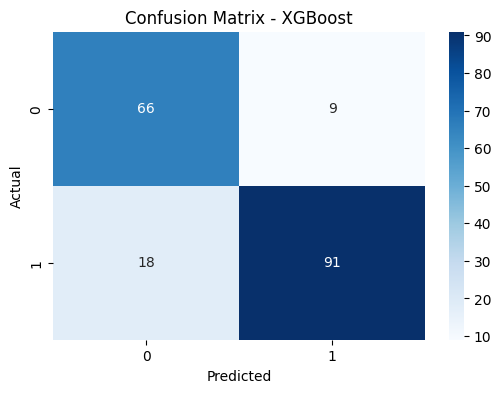

In [69]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83        75
           1       0.91      0.83      0.87       109

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



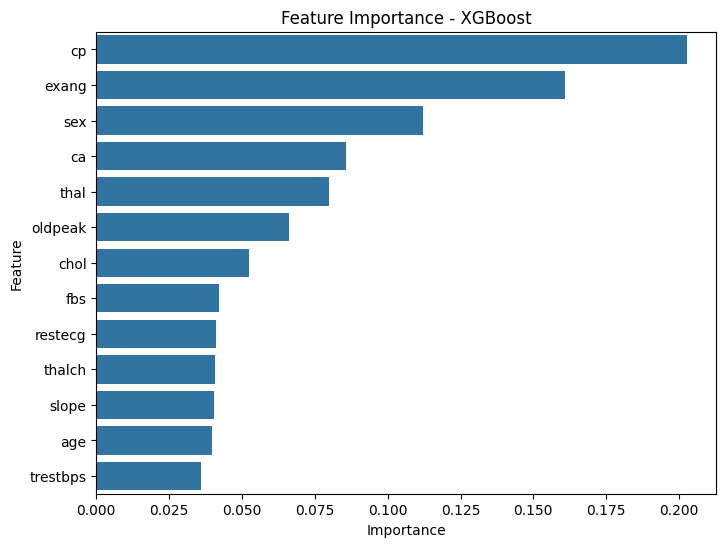

,Feature,Importance
2,cp,0.202649
8,exang,0.160736
1,sex,0.112274
11,ca,0.085650
12,thal,0.079883
9,oldpeak,0.066158
4,chol,0.052380
5,fbs,0.042229
6,restecg,0.041103
7,thalch,0.040776


In [71]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - XGBoost")
plt.show()

importance_df

In [72]:
import pickle

pickle.dump(xgb, open("xgb_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [74]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
